# Exploratory Data Analysis (EDA)

## Objective
This notebook explores the synthetic nurse demand dataset to verify that it exhibits
realistic temporal and shift-wise patterns consistent with a Sri Lankan public hospital ward.

This step builds confidence in the simulation before applying machine learning and optimization.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/synthetic_ground_truth.csv")
df["date"] = pd.to_datetime(df["date"])

df.head()


,date,shift,required_nurses
0,2024-01-01,M,11
1,2024-01-01,E,11
2,2024-01-01,N,4
3,2024-01-02,M,9
4,2024-01-02,E,6


In [9]:
print("Total records:", len(df))
print("Unique days:", df["date"].nunique())
print("Shifts:", df["shift"].unique())


Total records: 1080
Unique days: 360
Shifts: ['M' 'E' 'N']


**Observation**

- The dataset contains 3 records per day (Morning, Evening, Night).
- This confirms that the data generation process is consistent with the defined shift structure.


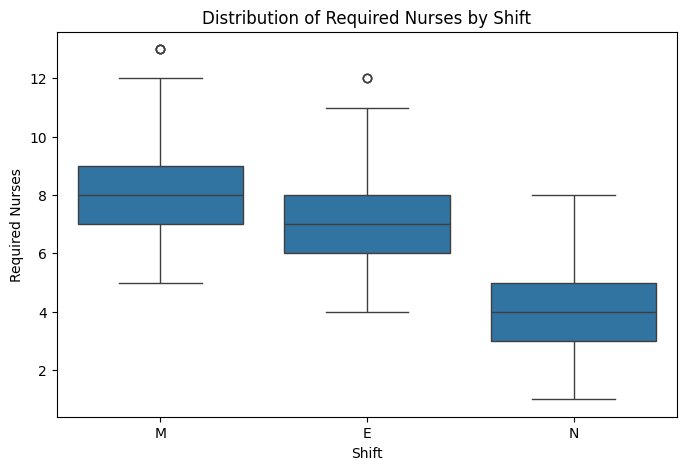

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="shift", y="required_nurses")
plt.title("Distribution of Required Nurses by Shift")
plt.xlabel("Shift")
plt.ylabel("Required Nurses")
plt.show()


**Interpretation**

- Morning (M) and Evening (E) shifts require more nurses than Night (N).
- Night shift demand is lower, reflecting reduced patient activity.
- The distributions show realistic variability, including occasional high-demand days.


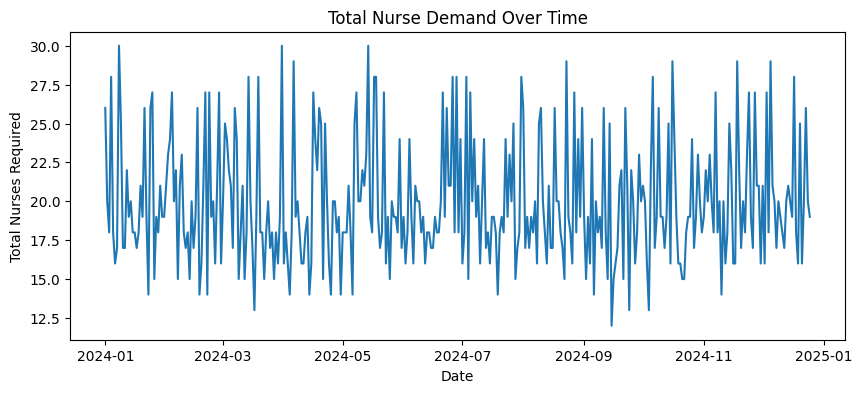

In [11]:
daily_total = df.groupby("date")["required_nurses"].sum()

plt.figure(figsize=(10,4))
plt.plot(daily_total)
plt.title("Total Nurse Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Nurses Required")
plt.show()


**Key Takeaway**

The synthetic dataset exhibits realistic temporal and shift-wise demand patterns,
making it suitable for forecasting and staffing optimization experiments.
